<a href="https://colab.research.google.com/github/Manav010203/Quiz/blob/cloudmain/03_pytorch_computer_vision_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pytorch Computer Vision

## 0. Computer vision libraries in Pytorch

* [`torchvision`] - base domain for computer vision in pytorch
* `torchvision.datasets` - get datasets and data loading fuctions for computer vision
* `torchvision.models` - get pretrained computer vision models that u can leverage for your own problems
* `torchvision.transforms` - functions for manipulating your vision data (images) to be suitable for use with an ML model
* `torch.utils.data.Dataset` - Base dataset class for Pytorch
* `torch.utils.data.DataLoader` - Creates a Python iterable over a dataset.

In [1]:
# import pytorch
import torch
from torch import nn

# import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# import matplotlib for visualization
import matplotlib.pyplot as plt

#check version
print(torch.__version__)
print(torchvision.__version__)

2.6.0+cu124
0.21.0+cu124


 ## 1. Getting a dataset.
 the dataset we will be using is FashionMNIST from torchvision datasets

In [2]:
# Setup Training data
train_data = torchvision.datasets.FashionMNIST(
    root="data", # where to download the data to?
    train=True, #do we want the training dataset?
    download=True, # do we want to download yes/no?
    transform = torchvision.transforms.ToTensor(),#how do we want to transform image to tensor?
    target_transform= None #how do we want to transform the labels/targets?
)
test_data =torchvision.datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None

)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 237kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.4MB/s]


In [3]:
len(train_data),len(test_data)

(60000, 10000)

In [4]:
#see the first training example
image,label = train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx =train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

##1.1 Check the input and output shapes of data

In [7]:
#check the shaoe of our image
image.shape,class_name[label]
#colorchannel,height,width. label

(torch.Size([1, 28, 28]), 'Ankle boot')

## 1.2 Visualizing our data

Image shape: torch.Size([1, 28, 28])
Label: 9


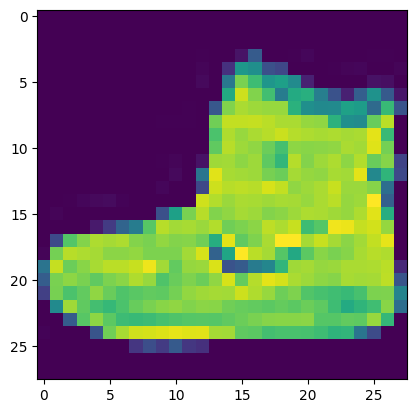

In [8]:
import matplotlib.pyplot as plt
image,label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label}")
plt.imshow(image.squeeze())

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

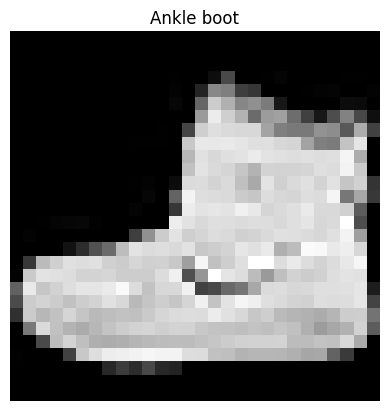

In [9]:
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_name[label])
plt.axis(False)

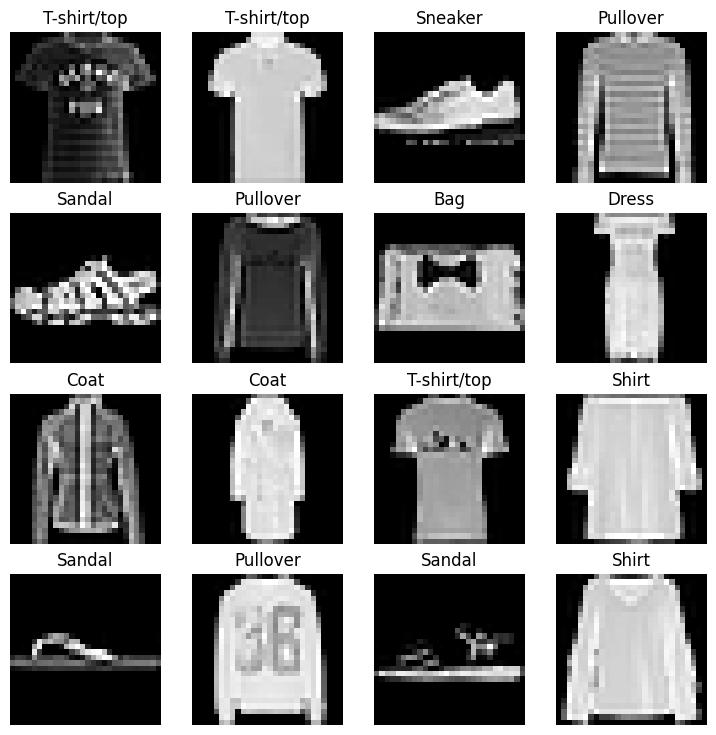

In [10]:
#plot more images
# torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
row,col=4,4
for i in range (1,row*col+1):
  random_idx=torch.randint(0,len(train_data),size=[1]).item()
  image ,label = train_data[random_idx]
  fig.add_subplot(row,col,i)
  plt.imshow(image.squeeze(),cmap="gray")
  plt.axis(False)
  plt.title(class_name[label])

Do you think these item of clothing(images) could be modified with pure linear lines? Or do you think we will need non-linearities

## 2. Prepare DataLoader

Right now, our data is in the form of Pytorch datasets

DataLoader turns our dataset into a python iterable

More specifically, we want to turn our data into batches

Why would we do this?

1. It is more computationally efficient, as in your computing hardware may not be able to look (store in memory) at 60000 images in one hit. So we break it down to 32 images at atime (btch size of 2).
2. It gives our neural network more chances to update its gradient per epoch.


In [ ]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE =32

# Turn datasets into iterable (batches)
train_dataloader = DataLoader()